In [6]:
import json

# Đọc file JSON
with open('auc_plot_data_phobert_mtl_ver_b.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Chỉnh sửa giá trị
for entry in data:
    entry['classifier'] = "PhoBERT-MTL-Ver-B"

# Ghi lại file mới
with open('auc_plot_data_phobert_mtl_ver_b.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

print("Done!")


Done!


Found 5 file(s): ['auc_plot_data_phobert_mtl_ver_a.json', 'auc_plot_data_phobert_mtl.json', 'auc_plot_data_phobertcnnlstm.json', 'auc_plot_data_phobert_mtl_ver_b.json', 'auc_plot_data_phobertbase.json']
Counting review length distribution from: auc_plot_data_phobert_mtl_ver_a.json
Processing file: auc_plot_data_phobert_mtl_ver_a.json
Processing file: auc_plot_data_phobert_mtl.json
Processing file: auc_plot_data_phobertcnnlstm.json
Processing file: auc_plot_data_phobert_mtl_ver_b.json
Processing file: auc_plot_data_phobertbase.json

Review length distribution (from first file):
  0_59    :  2064 reviews (63.86%)
  60_119  :   894 reviews (27.66%)
  120_179 :   191 reviews (5.91%)
  180_239 :    53 reviews (1.64%)
  240_299 :    18 reviews (0.56%)
  300_359 :     6 reviews (0.19%)
  360_419 :     3 reviews (0.09%)
  420_479 :     3 reviews (0.09%)
Total reviews: 3232

Chart saved to file: auc_by_review_length_start.png


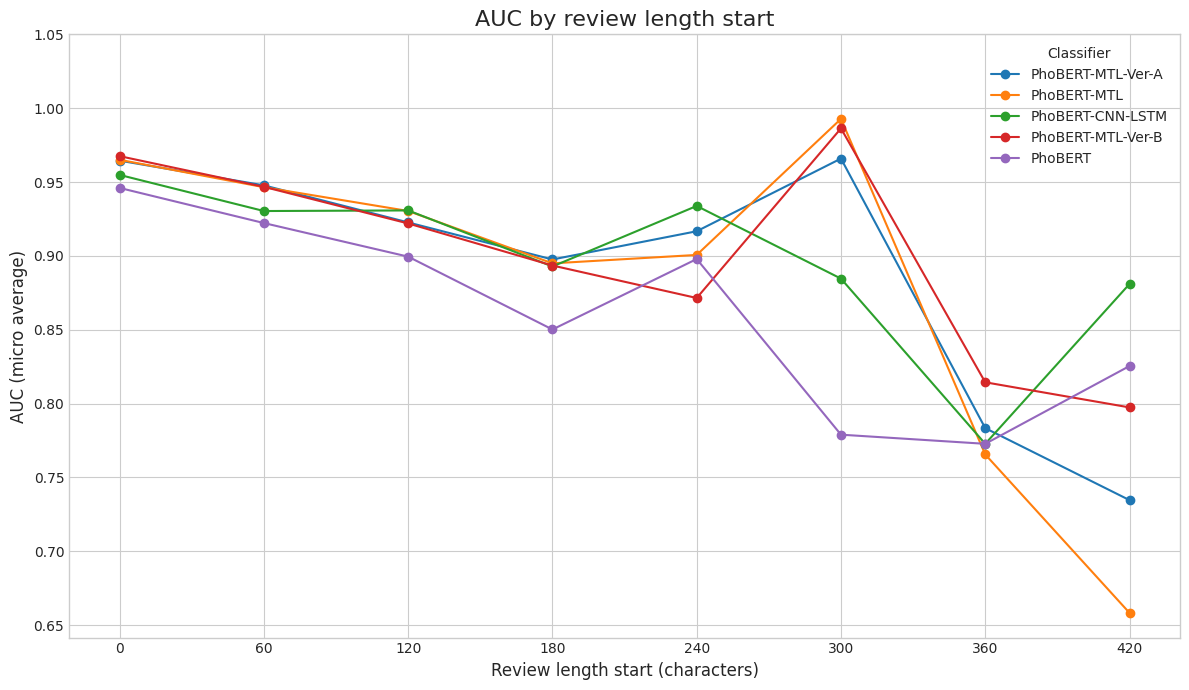

In [ ]:
import os
import glob
import json
from collections import defaultdict, OrderedDict, Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DATA_DIR = ""
BIN_SIZE = 60
MAX_LENGTH = 1000

json_files = glob.glob(os.path.join(DATA_DIR, "*.json"))

if not json_files:
    print(
        f"Error: No .json files found in directory '{DATA_DIR}'. Please check the DATA_DIR path."
    )
    exit()

print(f"Found {len(json_files)} file(s): {json_files}")

store = defaultdict(lambda: defaultdict(list))
length_range_counter = Counter()

def get_length_range_label(length, bin_size, max_length):
    if length >= max_length:
        return f"{max_length}+"
    range_start = (length // bin_size) * bin_size
    range_end = range_start + bin_size - 1
    return f"{range_start}_{range_end}"

first_file = json_files[0]
print(f"Counting review length distribution from: {first_file}")
with open(first_file, "r", encoding="utf-8") as f:
    try:
        records = json.load(f)
        for rec in records:
            L = rec.get("review_length")
            if L is not None:
                label = get_length_range_label(L, BIN_SIZE, MAX_LENGTH)
                length_range_counter[label] += 1
    except json.JSONDecodeError:
        print(
            f"  Warning: Failed to read JSON file '{first_file}' for length distribution."
        )

for fn in json_files:
    print(f"Processing file: {fn}")
    with open(fn, "r", encoding="utf-8") as f:
        try:
            records = json.load(f)
        except json.JSONDecodeError:
            print(f"  Warning: Failed to read JSON file '{fn}'. Skipping.")
            continue
    for rec in records:
        clf = rec.get("classifier", "Unknown")
        L = rec.get("review_length")
        y_true = rec.get("true_labels")
        y_score = rec.get("probabilities")
        if L is None or y_true is None or y_score is None:
            continue
        try:
            auc = roc_auc_score(y_true, y_score, average="micro")
        except ValueError:
            continue
        label = get_length_range_label(L, BIN_SIZE, MAX_LENGTH)
        store[clf][label].append(auc)

plot_data = {}
all_ranges = set()

for clf, d in store.items():
    for label in d.keys():
        all_ranges.add(label)

sorted_ranges = sorted(
    list(all_ranges),
    key=lambda b: int(b.split("_")[0]) if "+" not in b else MAX_LENGTH,
)

for clf, d in store.items():
    od = OrderedDict()
    for label in sorted_ranges:
        if label in d:
            aucs = d[label]
            od[label] = sum(aucs) / len(aucs)
        else:
            od[label] = np.nan
    plot_data[clf] = od

total_reviews = sum(length_range_counter.values())
print("\nReview length distribution (from first file):")
for label in sorted_ranges:
    count = length_range_counter[label]
    percent = (count / total_reviews) * 100 if total_reviews else 0
    print(f"  {label:<8}: {count:>5} reviews ({percent:.2f}%)")
print(f"Total reviews: {total_reviews}\n")

def range_label_to_start(label):
    if "+" in label:
        return MAX_LENGTH
    start = int(label.split("_")[0])
    return start

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12, 7))

for clf, od in plot_data.items():
    labels = list(od.keys())
    values = list(od.values())
    x_numeric = [range_label_to_start(lbl) for lbl in labels]
    plt.plot(x_numeric, values, marker="o", linestyle="-", label=clf)

plt.xlabel("Review length start (characters)", fontsize=12)
plt.ylabel("AUC (micro average)", fontsize=12)
plt.title("AUC by review length start", fontsize=16)
plt.legend(title="Classifier", fontsize=10)

x_ticks = [range_label_to_start(lbl) for lbl in sorted_ranges]
plt.xticks(x_ticks, x_ticks)

plt.ylim(bottom=max(0, plt.ylim()[0]), top=1.05)
plt.tight_layout()

output_filename = "auc_by_review_length_start.png"
plt.savefig(output_filename, dpi=300)
print(f"Chart saved to file: {output_filename}")

plt.show()

In [9]:
import json
import os

# Các mốc độ dài ký tự
length_checkpoints = [0, 60, 120, 180, 240, 300, 360, 420]

# Đọc dataset từ file
input_file = "output_semeval_format_v6_no_overlap_biotag.json"  # thay bằng file của bạn
with open(input_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Lấy danh sách câu
data = raw_data["sentence"]  # vì file chứa key "sentence"

# Tạo thư mục lưu kết quả
output_dir = "length_filtered"
os.makedirs(output_dir, exist_ok=True)

# Hàm lấy khoảng độ dài
def get_length_range(length):
    for i in range(len(length_checkpoints) - 1):
        if length_checkpoints[i] <= length < length_checkpoints[i + 1]:
            return (length_checkpoints[i], length_checkpoints[i + 1])
    return None

# Tạo dict chứa các câu theo khoảng
buckets = {}
for i in range(len(length_checkpoints) - 1):
    buckets[(length_checkpoints[i], length_checkpoints[i + 1])] = []

# Phân loại câu
for sentence in data:
    text = sentence["text"].strip()
    length = len(text)
    length_range = get_length_range(length)
    if length_range:
        # Chỉ giữ text và aspects, bỏ tokens và bio_tags
        filtered_aspects = []
        for asp in sentence.get("aspects", []):
            filtered_aspects.append({
                "term": asp["term"],
                "category": asp["category"],
                "polarity": asp["polarity"],
                "from": asp["from"],
                "to": asp["to"]
            })
        buckets[length_range].append({
            "text": text,
            "aspects": filtered_aspects
        })

# Lưu từng khoảng ra file
for (low, high), sentences in buckets.items():
    if sentences:  # chỉ lưu nếu có dữ liệu
        output_path = os.path.join(output_dir, f"{low}_{high}.json")
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(sentences, f, ensure_ascii=False, indent=2)
        print(f"✅ Lưu {len(sentences)} câu vào {output_path}")

✅ Lưu 10427 câu vào length_filtered/0_60.json
✅ Lưu 4416 câu vào length_filtered/60_120.json
✅ Lưu 965 câu vào length_filtered/120_180.json
✅ Lưu 243 câu vào length_filtered/180_240.json
✅ Lưu 71 câu vào length_filtered/240_300.json
✅ Lưu 27 câu vào length_filtered/300_360.json
✅ Lưu 9 câu vào length_filtered/360_420.json


In [ ]:
import os
import glob
import json
from collections import defaultdict, OrderedDict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DATA_DIR = ""
BIN_SIZE = 40
MAX_LENGTH = 500

json_files = glob.glob(os.path.join(DATA_DIR, "*.json"))

if not json_files:
    print(f"Lỗi: Không tìm thấy file .json nào trong thư mục '{DATA_DIR}'. Vui lòng kiểm tra lại đường dẫn DATA_DIR.")
    exit()

print(f"Tìm thấy {len(json_files)} file(s): {json_files}")

store = defaultdict(lambda: defaultdict(list))

def get_bin_label(length, bin_size, max_length):
    if length >= max_length:
        return f"{max_length}+"
    bin_start = (length // bin_size) * bin_size
    bin_end = bin_start + bin_size - 1
    return f"{bin_start}-{bin_end}"

for fn in json_files:
    print(f"Đang xử lý file: {fn}")
    with open(fn, "r", encoding="utf-8") as f:
        try:
            records = json.load(f)
        except json.JSONDecodeError:
            print(f"  Cảnh báo: Không thể đọc file JSON '{fn}'. Bỏ qua.")
            continue
    for rec in records:
        clf = rec.get("classifier", "Unknown")
        L = rec.get("review_length")
        y_true = rec.get("true_labels")
        y_score = rec.get("probabilities")
        if L is None or y_true is None or y_score is None:
            continue
        try:
            auc = roc_auc_score(y_true, y_score, average='micro')
        except ValueError:
            continue
        bin_label = get_bin_label(L, BIN_SIZE, MAX_LENGTH)
        store[clf][bin_label].append(auc)

plot_data = {}
all_bins = set()

for clf, d in store.items():
    for bin_label in d.keys():
        all_bins.add(bin_label)

sorted_bins = sorted(list(all_bins), key=lambda b: int(b.split('-')[0]) if '+' not in b else MAX_LENGTH)

for clf, d in store.items():
    od = OrderedDict()
    for bin_label in sorted_bins:
        aucs = d.get(bin_label)
        if aucs and len(aucs) > 1:
            mean_auc = np.mean(aucs)
            std_dev = np.std(aucs)
            od[bin_label] = {'mean': mean_auc, 'std': std_dev, 'count': len(aucs)}
        elif aucs:
            od[bin_label] = {'mean': np.mean(aucs), 'std': 0, 'count': len(aucs)}
    plot_data[clf] = od

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))

styles = {
    "PhoBERT-MTL": {"marker": "o", "linestyle": "-", "color": "C0"},
    "PhoBERT": {"marker": "s", "linestyle": "--", "color": "C1"},
    "PhoBERT-CNN-LSTM": {"marker": "^", "linestyle": ":", "color": "C2"}
}

for clf, od in plot_data.items():
    labels = list(od.keys())
    means = [data['mean'] for data in od.values()]
    stds = [data['std'] for data in od.values()]
    style = styles.get(clf, {"marker": "x", "linestyle": "-.", "color": "C3"})
    plt.errorbar(labels, means, yerr=stds, label=clf, capsize=4, **style)

plt.xlabel("Review length (số ký tự theo khoảng)", fontsize=12)
plt.ylabel("AUC (micro average)", fontsize=12)
plt.title("AUC theo khoảng độ dài của review (kèm độ lệch chuẩn)", fontsize=16)
plt.legend(title="Classifier", fontsize=10)
plt.xticks(rotation=60, ha='right')
plt.ylim(bottom=0.5, top=1.05)
plt.tight_layout()

output_filename = "auc_by_binned_length_professional.png"
plt.savefig(output_filename, dpi=300)
print(f"Biểu đồ đã được lưu vào file: {output_filename}")

plt.show()

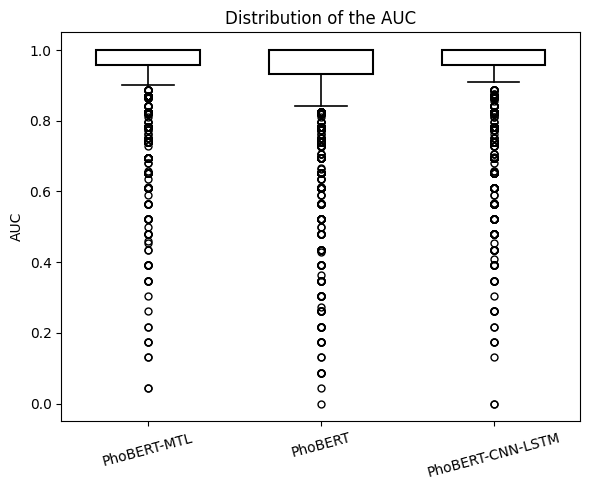

In [1]:
import json
import glob
import os
from collections import defaultdict
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Thư mục chứa JSON
DATA_DIR = ""
json_files = glob.glob(os.path.join(DATA_DIR, "*.json"))

# AUC theo classifier
auc_per_clf = defaultdict(list)

for fn in json_files:
    with open(fn, 'r', encoding='utf-8') as f:
        records = json.load(f)

    for rec in records:
        clf = rec["classifier"]
        y_true = rec["true_labels"]
        y_pred = rec["probabilities"]
        try:
            auc = roc_auc_score(y_true, y_pred)
            auc_per_clf[clf].append(auc)
        except ValueError:
            continue  # bỏ qua nếu chỉ có 1 class

# Chuẩn bị dữ liệu plot
labels = list(auc_per_clf.keys())
data = [auc_per_clf[label] for label in labels]

# Plot boxplot
plt.figure(figsize=(6, 5))
box = plt.boxplot(data, patch_artist=True, widths=0.6)

# Tô màu box (đen trắng giống Fig. 5)
for patch in box['boxes']:
    patch.set(facecolor='white', edgecolor='black', linewidth=1.5)
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.2)
for cap in box['caps']:
    cap.set(color='black', linewidth=1.2)
for median in box['medians']:
    median.set(color='black', linewidth=1.2)
for flier in box['fliers']:
    flier.set(marker='o', color='black', markersize=5)

plt.xticks(ticks=range(1, len(labels) + 1), labels=labels, rotation=15)
plt.ylabel("AUC")
plt.title("Distribution of the AUC")
plt.tight_layout()

# Lưu ảnh
plt.savefig("auc_distribution_boxplot.png", dpi=200)
plt.show()


Tìm thấy 3 file(s): ['auc_plot_data_phobert_mtl.json', 'auc_plot_data_phobertbase.json', 'auc_plot_data_phobertcnnlstm.json']
Đang xử lý file: auc_plot_data_phobert_mtl.json
Đang xử lý file: auc_plot_data_phobertbase.json
Đang xử lý file: auc_plot_data_phobertcnnlstm.json


/tmp/ipykernel_1758/2374623371.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Biểu đồ đã được lưu vào file: auc_distribution_boxplot.png


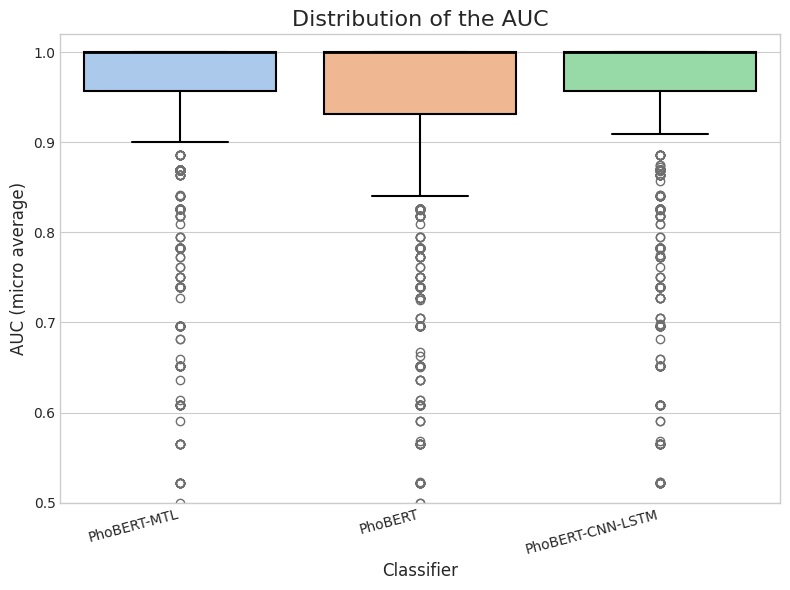


Thống kê mô tả AUC theo từng Classifier:
                   count      mean       std       min       25%  50%  75%  \
Classifier                                                                   
PhoBERT           3234.0  0.934476  0.135397  0.000000  0.931818  1.0  1.0   
PhoBERT-CNN-LSTM  3234.0  0.945379  0.114515  0.000000  0.956522  1.0  1.0   
PhoBERT-MTL       3232.0  0.957142  0.097763  0.043478  0.956522  1.0  1.0   

                  max  
Classifier             
PhoBERT           1.0  
PhoBERT-CNN-LSTM  1.0  
PhoBERT-MTL       1.0  


In [2]:
import os
import glob
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = "" 
SHOW_OUTLIERS = True 
Y_LOWER_LIMIT = 0.5

json_files = glob.glob(os.path.join(DATA_DIR, "*.json"))

if not json_files:
    print(f"Lỗi: Không tìm thấy file .json nào trong thư mục '{DATA_DIR}'. Vui lòng kiểm tra lại đường dẫn DATA_DIR.")
    exit()

print(f"Tìm thấy {len(json_files)} file(s): {json_files}")

all_data = []

for fn in json_files:
    print(f"Đang xử lý file: {fn}")
    with open(fn, "r", encoding="utf-8") as f:
        try:
            records = json.load(f)
        except json.JSONDecodeError:
            print(f"  Cảnh báo: Không thể đọc file JSON '{fn}'. Bỏ qua.")
            continue
            
    for rec in records:
        clf = rec.get("classifier", "Unknown")
        y_true = rec.get("true_labels")
        y_score = rec.get("probabilities")

        if y_true is None or y_score is None:
            continue

        try:
            from sklearn.metrics import roc_auc_score
            auc = roc_auc_score(y_true, y_score, average='micro')
            all_data.append({"Classifier": clf, "AUC": auc})
        except ValueError:
            continue

df = pd.DataFrame(all_data)

if df.empty:
    print("Không có dữ liệu hợp lệ để vẽ biểu đồ. Vui lòng kiểm tra lại nội dung các file JSON.")
    exit()

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x="Classifier", 
    y="AUC", 
    data=df,
    showfliers=SHOW_OUTLIERS,
    palette="pastel",
    boxprops=dict(edgecolor='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
)

plt.xlabel("Classifier", fontsize=12)
plt.ylabel("AUC (micro average)", fontsize=12)
plt.title("Distribution of the AUC", fontsize=16)

plt.xticks(rotation=15, ha='right')
plt.ylim(bottom=Y_LOWER_LIMIT, top=1.02)

plt.tight_layout()

output_filename = "auc_distribution_boxplot.png"
plt.savefig(output_filename, dpi=300)
print(f"Biểu đồ đã được lưu vào file: {output_filename}")

plt.show()

print("\nThống kê mô tả AUC theo từng Classifier:")
print(df.groupby('Classifier')['AUC'].describe())